This notebook shows you how to visualize the changes in ozone and particulate matter from different runs of CCTM. Note that you must first run the `combine` program distributed with CMAQ for the files here to exist. The need for postprocessing of CCTM outputs is explained in [this section](https://github.com/USEPA/CMAQ/blob/main/DOCS/Users_Guide/CMAQ_UG_ch08_analysis_tools.md#82-aggregating-and-transforming-model-species) of the CMAQ User's Guide.

In [17]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib import cm
from cmaqpy.runcmaq import CMAQModel
from cmaqpy import plots
from cmaqpy import utils

import monet as m
import monetio as mio

In [3]:
# Specify the start/end times
start_datetime = 'August 06, 2016'  # first day that you want run
end_datetime = 'August 14, 2016'  # last day you want run
# Define the coordinate name (must match that in GRIDDESC)
coord_name = 'LAM_40N97W'
# Create a CMAQModel object
base_sim = CMAQModel(start_datetime, end_datetime, '2016Base_12OTC2', coord_name, '12OTC2', 
    setup_yaml='dirpaths_2016Base_12OTC2.yml', verbose=True)
s0_sim = CMAQModel(start_datetime, end_datetime, '2016_12OTC2', coord_name, '12OTC2', 
    setup_yaml='dirpaths_2016_12OTC2.yml', verbose=True)

Application name: 2016Base_12OTC2
Coordinate name: LAM_40N97W
Grid name: 12OTC2
CCTM RUNID: v533_gcc9.3.1_2016Base_12OTC2
CMAQ run starting on: 2016-08-06 00:00:00
CMAQ run ending on: 2016-08-14 00:00:00
Application name: 2016_12OTC2
Coordinate name: LAM_40N97W
Grid name: 12OTC2
CCTM RUNID: v533_gcc9.3.1_2016_12OTC2
CMAQ run starting on: 2016-08-06 00:00:00
CMAQ run ending on: 2016-08-14 00:00:00


In [8]:
%%capture
emis_dir = '/share/mzhang/jas983/emissions_data/nei_platform2016/v1/2016fh_16j/smoke_out/2016fh_16j/12OTC2/cmaq_cb6/'

emis_base1 = f'{emis_dir}/ptertac/2d_mole_ptertac_20160806_12OTC2_cmaq_cb6_2016fh_16j.ncf'
emis_base2 = f'{emis_dir}/ptertac/2d_mole_ptertac_20160807_12OTC2_cmaq_cb6_2016fh_16j.ncf'
emis_base3 = f'{emis_dir}/ptertac/2d_mole_ptertac_20160808_12OTC2_cmaq_cb6_2016fh_16j.ncf'
emis_base4 = f'{emis_dir}/ptertac/2d_mole_ptertac_20160809_12OTC2_cmaq_cb6_2016fh_16j.ncf'
emis_base5 = f'{emis_dir}/ptertac/2d_mole_ptertac_20160810_12OTC2_cmaq_cb6_2016fh_16j.ncf'
emis_base6 = f'{emis_dir}/ptertac/2d_mole_ptertac_20160811_12OTC2_cmaq_cb6_2016fh_16j.ncf'
emis_base7 = f'{emis_dir}/ptertac/2d_mole_ptertac_20160812_12OTC2_cmaq_cb6_2016fh_16j.ncf'
emis_base8 = f'{emis_dir}/ptertac/2d_mole_ptertac_20160813_12OTC2_cmaq_cb6_2016fh_16j.ncf'
e_base1 = mio.cmaq.open_dataset(fname=emis_base1)
e_base2 = mio.cmaq.open_dataset(fname=emis_base2)
e_base3 = mio.cmaq.open_dataset(fname=emis_base3)
e_base4 = mio.cmaq.open_dataset(fname=emis_base4)
e_base5 = mio.cmaq.open_dataset(fname=emis_base5)
e_base6 = mio.cmaq.open_dataset(fname=emis_base6)
e_base7 = mio.cmaq.open_dataset(fname=emis_base7)
e_base8 = mio.cmaq.open_dataset(fname=emis_base8)
e_base = xr.concat([e_base1, e_base2, e_base3, e_base4, e_base5, e_base6, e_base7, e_base8], dim='time')

emis_ren1 = f'{emis_dir}/ptertac_s0/2d_mole_ptertac_20160806_12OTC2_cmaq_cb6_2016fh_16j.ncf'
emis_ren2 = f'{emis_dir}/ptertac_s0/2d_mole_ptertac_20160807_12OTC2_cmaq_cb6_2016fh_16j.ncf'
emis_ren3 = f'{emis_dir}/ptertac_s0/2d_mole_ptertac_20160808_12OTC2_cmaq_cb6_2016fh_16j.ncf'
emis_ren4 = f'{emis_dir}/ptertac_s0/2d_mole_ptertac_20160809_12OTC2_cmaq_cb6_2016fh_16j.ncf'
emis_ren5 = f'{emis_dir}/ptertac_s0/2d_mole_ptertac_20160810_12OTC2_cmaq_cb6_2016fh_16j.ncf'
emis_ren6 = f'{emis_dir}/ptertac_s0/2d_mole_ptertac_20160811_12OTC2_cmaq_cb6_2016fh_16j.ncf'
emis_ren7 = f'{emis_dir}/ptertac_s0/2d_mole_ptertac_20160812_12OTC2_cmaq_cb6_2016fh_16j.ncf'
emis_ren8 = f'{emis_dir}/ptertac_s0/2d_mole_ptertac_20160813_12OTC2_cmaq_cb6_2016fh_16j.ncf'
e_ren1 = mio.cmaq.open_dataset(fname=emis_ren1)
e_ren2 = mio.cmaq.open_dataset(fname=emis_ren2)
e_ren3 = mio.cmaq.open_dataset(fname=emis_ren3)
e_ren4 = mio.cmaq.open_dataset(fname=emis_ren4)
e_ren5 = mio.cmaq.open_dataset(fname=emis_ren5)
e_ren6 = mio.cmaq.open_dataset(fname=emis_ren6)
e_ren7 = mio.cmaq.open_dataset(fname=emis_ren7)
e_ren8 = mio.cmaq.open_dataset(fname=emis_ren8)
e_ren = xr.concat([e_ren1, e_ren2, e_ren3, e_ren4, e_ren5, e_ren6, e_ren7, e_ren8], dim='time')

In [12]:
# Drop duplicate times
_, index = np.unique(e_base['time'], return_index=True)
e_base = e_base.isel(time=index)
_, index = np.unique(e_ren['time'], return_index=True)
e_ren = e_ren.isel(time=index)

In [15]:
# Drop final time slice
e_base = e_base.isel(time=slice(0, -1))
e_ren = e_ren.isel(time=slice(0, -1))

In [18]:
# Convert to Eastern Time
e_base = utils.convert_tz_xr(e_base)
e_ren = utils.convert_tz_xr(e_ren)

In [19]:
e_ren

<xarray.Dataset>
Dimensions:       (DATE-TIME: 2, VAR: 58, time: 192, x: 273, y: 246, z: 1)
Coordinates:
  * time          (time) datetime64[ns] 2016-08-05T20:00:00 ... 2016-08-13T19...
    longitude     (y, x) float64 -106.0 -105.9 -105.8 ... -65.29 -65.14 -64.99
    latitude      (y, x) float64 25.18 25.19 25.2 25.21 ... 48.31 48.28 48.24
Dimensions without coordinates: DATE-TIME, VAR, x, y, z
Data variables: (12/61)
    TFLAG         (time, VAR, DATE-TIME) int32 2016219 0 ... 2016226 230000
    BUTADIENE13   (time, z, y, x) float32 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    ACROLEIN      (time, z, y, x) float32 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    HCL           (time, z, y, x) float32 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    CL2           (time, z, y, x) float32 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    CO            (time, z, y, x) float32 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    ...            ...
    TOL           (time, z, y, x) float32 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    UNR           (time, z, y, x) float32 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    XYLMN         (time, z, y, x) float32 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    VOC_INV       (time, z, y, x) float32 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    NOy           (time, z, y, x) float32 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    NOx           (time, z, y, x) float32 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes: (12/34)
    IOAPI_VERSION:  ioapi-3.2: $Id: init3.F90 200 2021-05-10 14:06:20Z coats ...
    EXEC_ID:        ????????????????                                         ...
    FTYPE:          1
    CDATE:          2022078
    CTIME:          195844
    WDATE:          2022078
    ...             ...
    GDNAM:          12OTC2          
    UPNAM:          INLINETO2D      
    VAR-LIST:       BUTADIENE13     ACROLEIN        HCL             CL2      ...
    FILEDESC:       Point  source stack groups file                          ...
    HISTORY:        
    proj4_srs:      +proj=lcc +lat_1=33.0 +lat_2=45.0 +lat_0=40.0 +lon_0=-97....

/home/jas983/anaconda3/envs/oshwind/lib/python3.8/site-packages/cartopy/mpl/geoaxes.py:1597: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  X, Y, C, shading = self._pcolorargs('pcolormesh', *args,


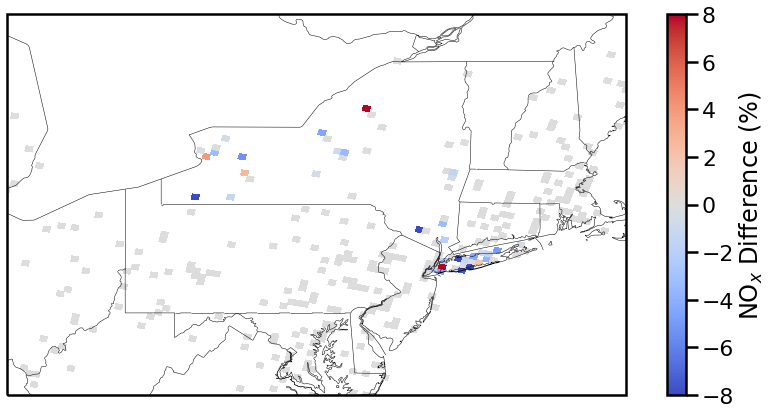

In [30]:
# Plot the mean difference in NOx
nox_pct_diff = (e_ren.NO + e_ren.NO2 - e_base.NO - e_base.NO2) / (e_base.NO + e_base.NO2) * 100
mean_nox_diff = nox_pct_diff.mean(dim='time')
plots.pollution_plot(mean_nox_diff, vmin=-8, vmax=8, cmap=cm.get_cmap('coolwarm'), 
                     extent = [-83, -70, 38, 46],
                     cbar_label='NO$_{x}$ Difference (%)', 
                     titlestr=None, 
                     savefig=True, figpath=f'../cmaqpy/data/plots/mean_NOx_diff.png')

/home/jas983/anaconda3/envs/oshwind/lib/python3.8/site-packages/cartopy/mpl/geoaxes.py:1597: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  X, Y, C, shading = self._pcolorargs('pcolormesh', *args,


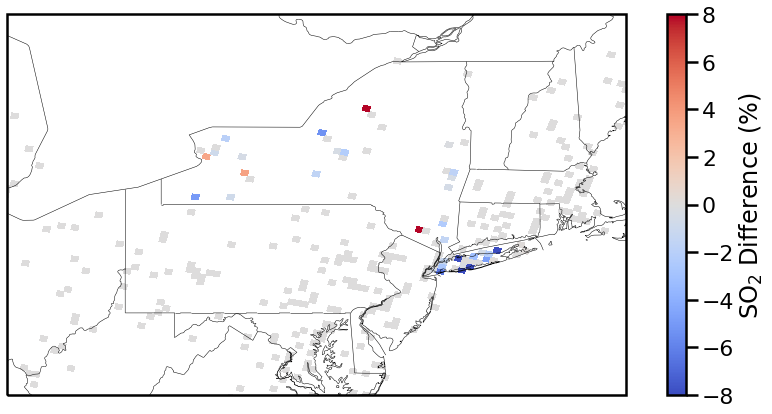

In [34]:
# Plot the mean difference in SO2
so2_pct_diff = (e_ren.SO2 - e_base.SO2) / e_base.SO2 * 100
mean_so2_diff = so2_pct_diff.mean(dim='time')
plots.pollution_plot(mean_so2_diff, vmin=-8, vmax=8, cmap=cm.get_cmap('coolwarm'), 
                     extent = [-83, -70, 38, 46],
                     cbar_label='SO$_{2}$ Difference (%)', 
                     titlestr=None, savefig=True, figpath=f'../cmaqpy/data/plots/mean_SO2_diff.png')

2016-08-11 20:00


/home/jas983/anaconda3/envs/oshwind/lib/python3.8/site-packages/cartopy/mpl/geoaxes.py:1597: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  X, Y, C, shading = self._pcolorargs('pcolormesh', *args,


2016-08-11 21:00


/home/jas983/anaconda3/envs/oshwind/lib/python3.8/site-packages/cartopy/mpl/geoaxes.py:1597: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  X, Y, C, shading = self._pcolorargs('pcolormesh', *args,


2016-08-11 22:00


...

/home/jas983/anaconda3/envs/oshwind/lib/python3.8/site-packages/cartopy/mpl/geoaxes.py:1597: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  X, Y, C, shading = self._pcolorargs('pcolormesh', *args,


2016-08-12 19:00


/home/jas983/anaconda3/envs/oshwind/lib/python3.8/site-packages/cartopy/mpl/geoaxes.py:1597: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  X, Y, C, shading = self._pcolorargs('pcolormesh', *args,


2016-08-12 20:00


/home/jas983/anaconda3/envs/oshwind/lib/python3.8/site-packages/cartopy/mpl/geoaxes.py:1597: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  X, Y, C, shading = self._pcolorargs('pcolormesh', *args,


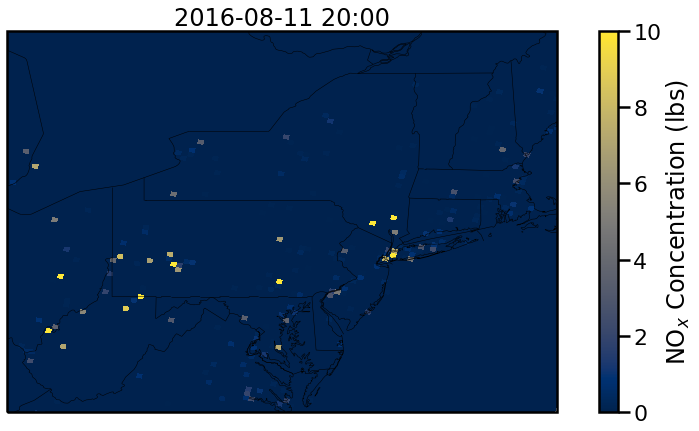

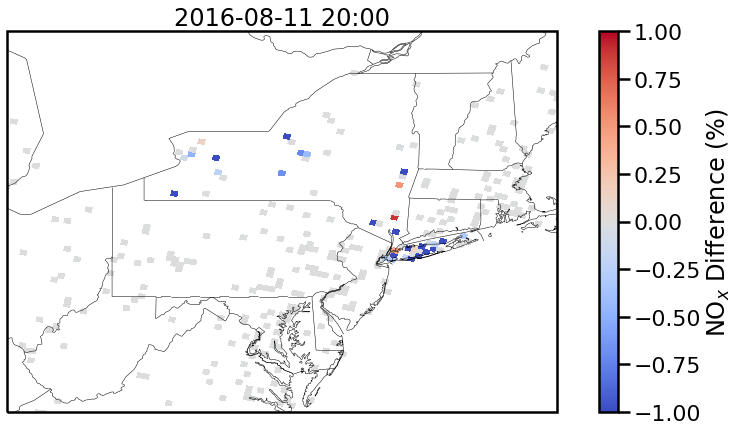

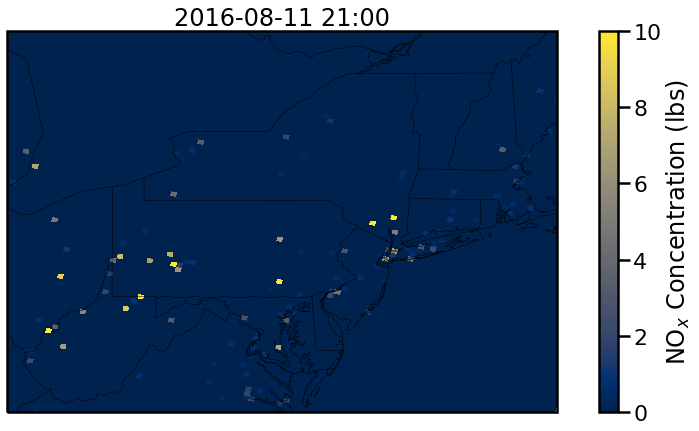

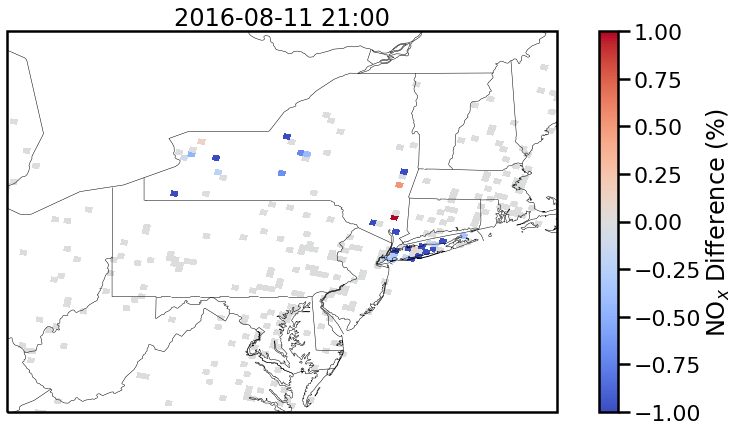

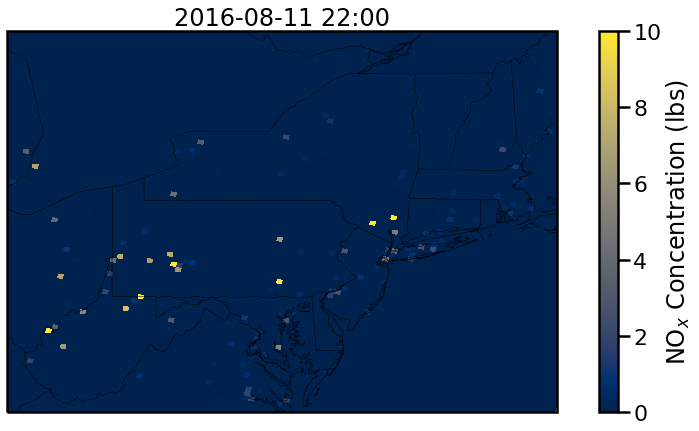

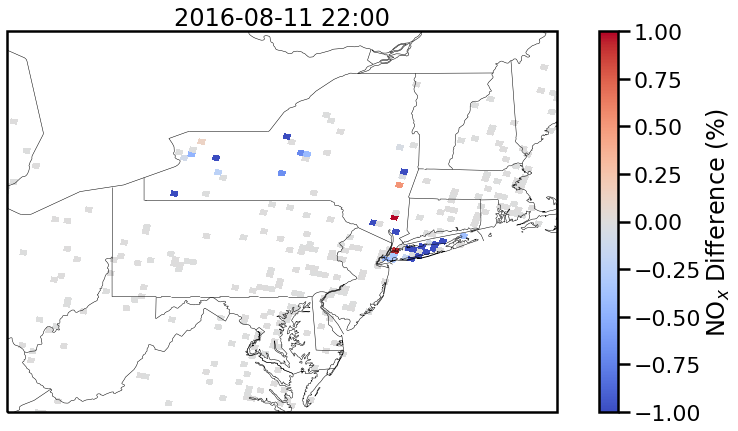

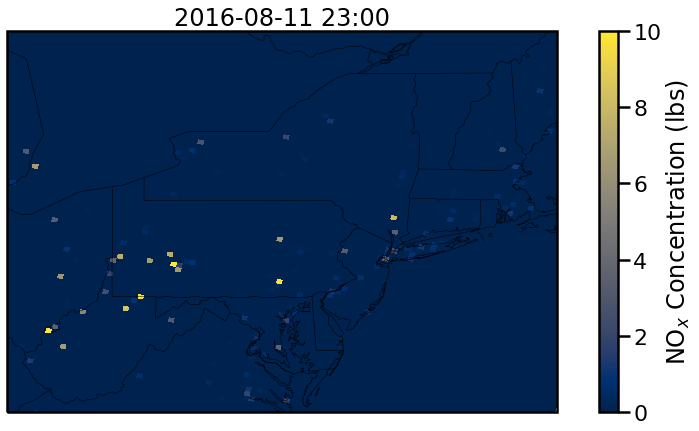

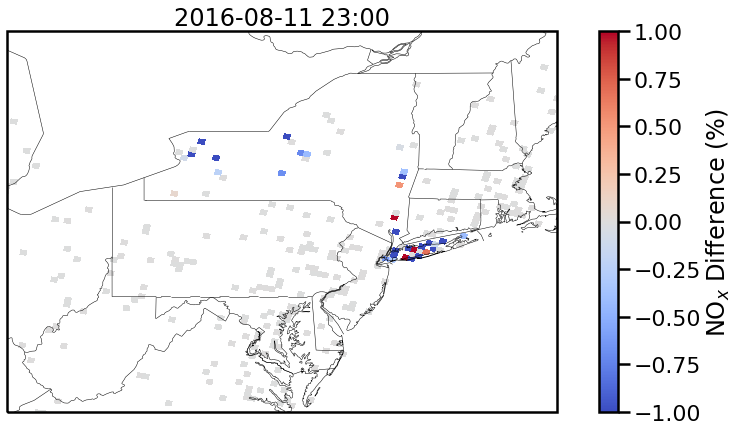

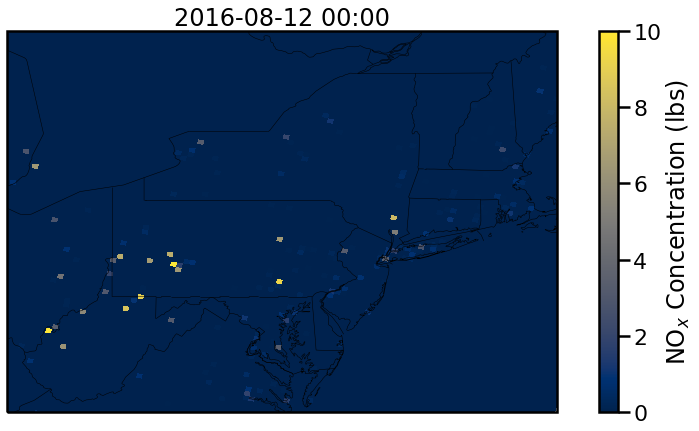

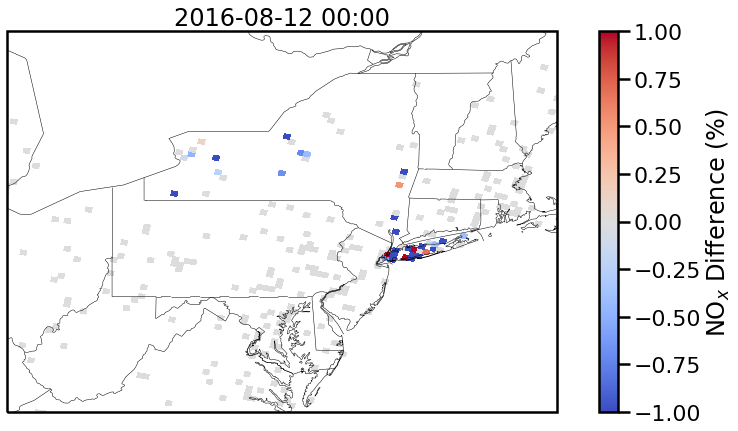

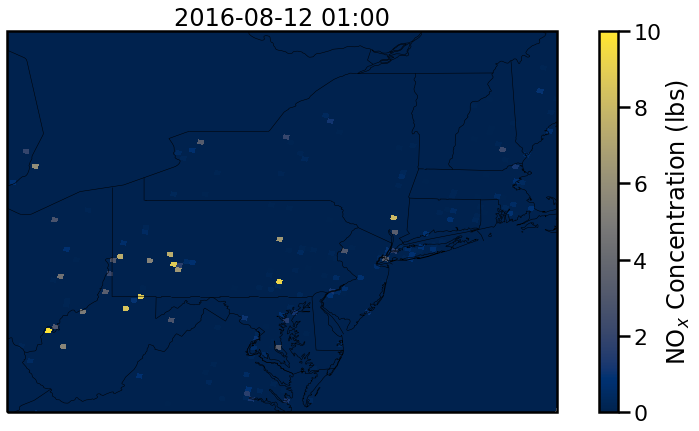

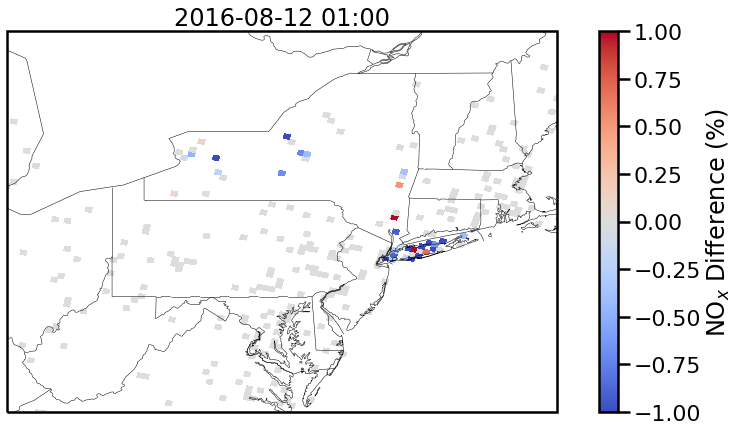

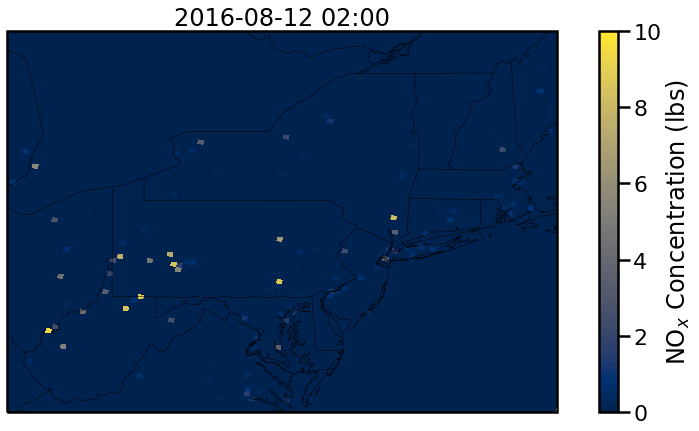

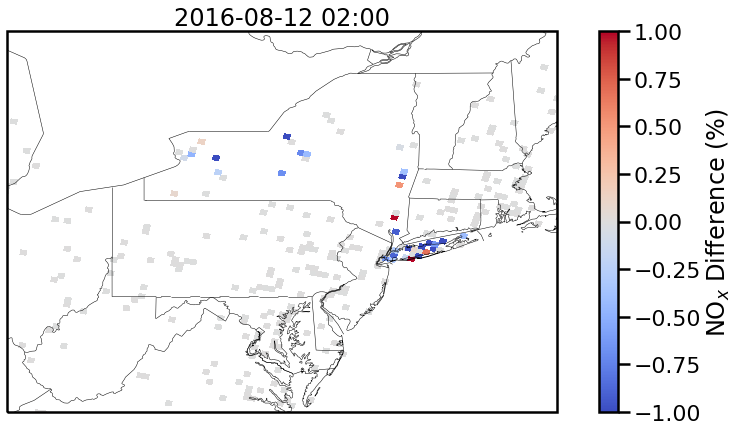

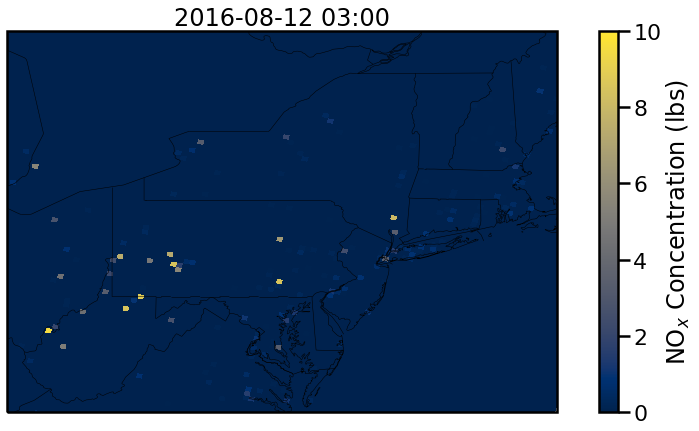

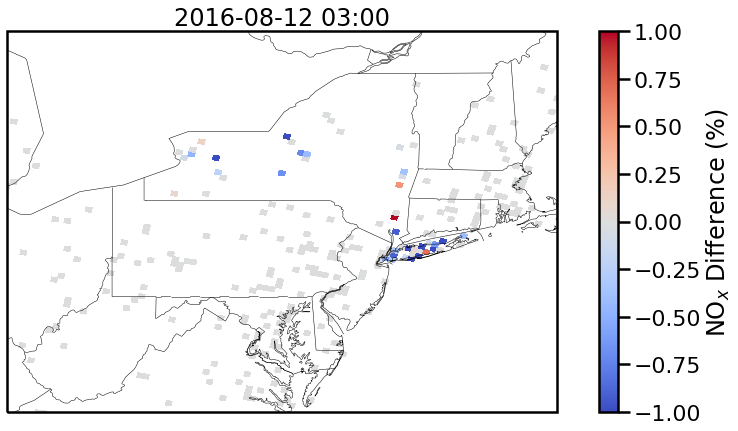

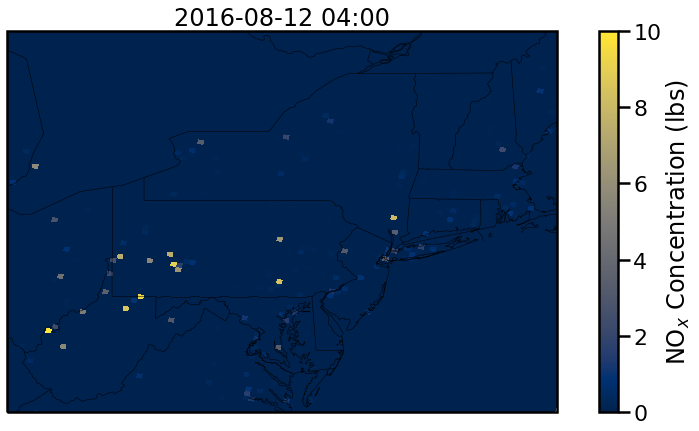

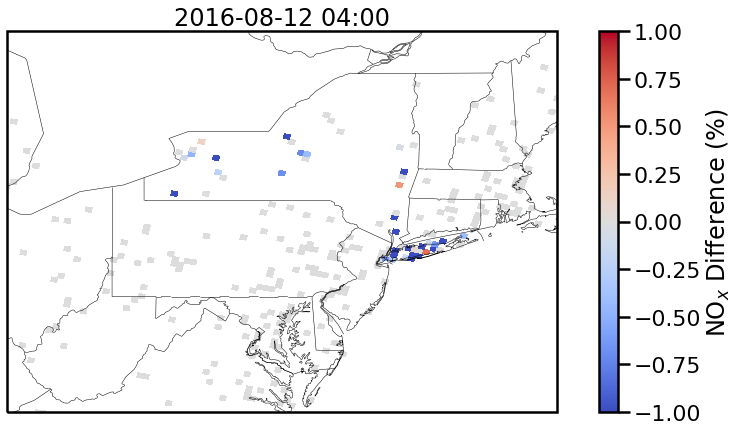

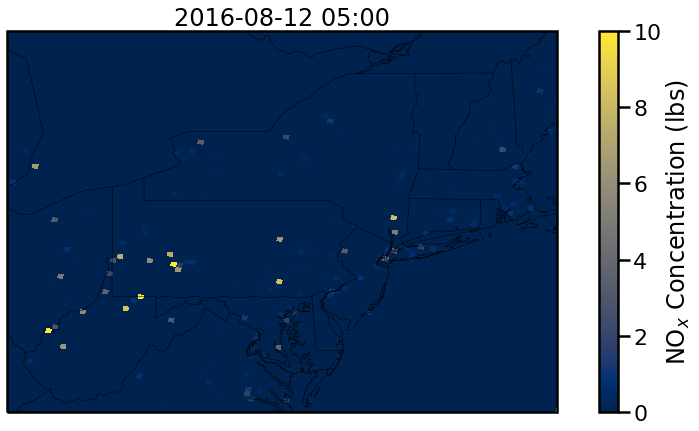

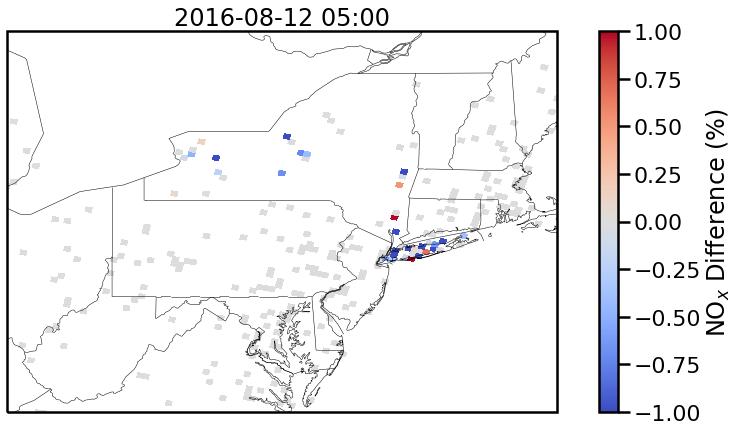

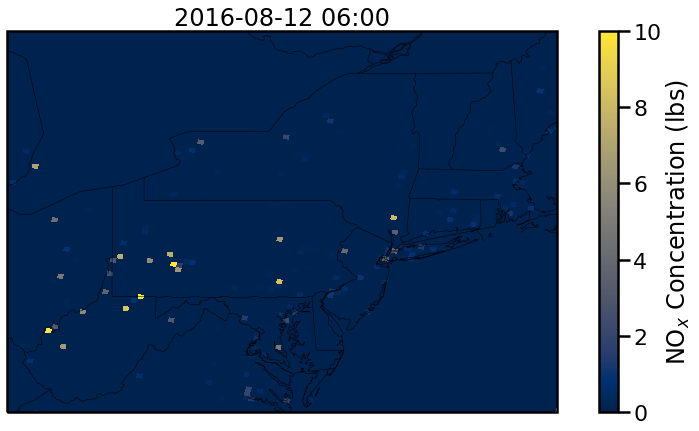

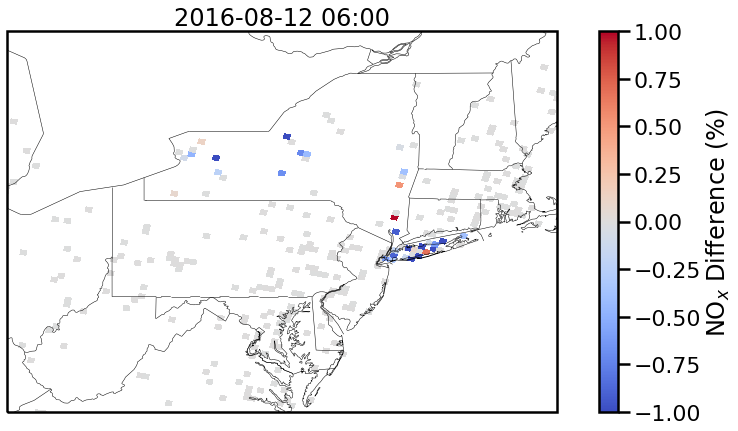

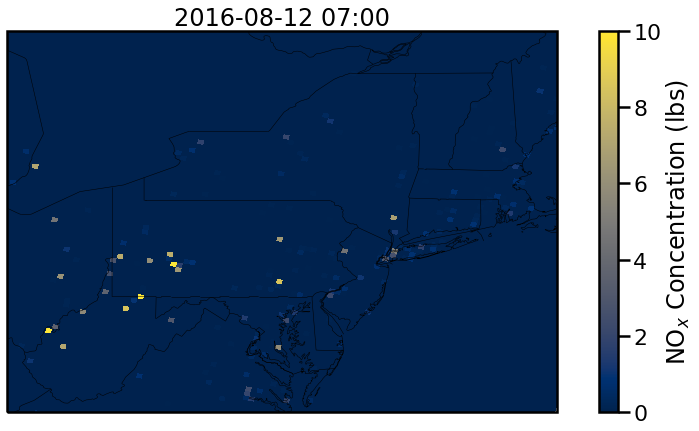

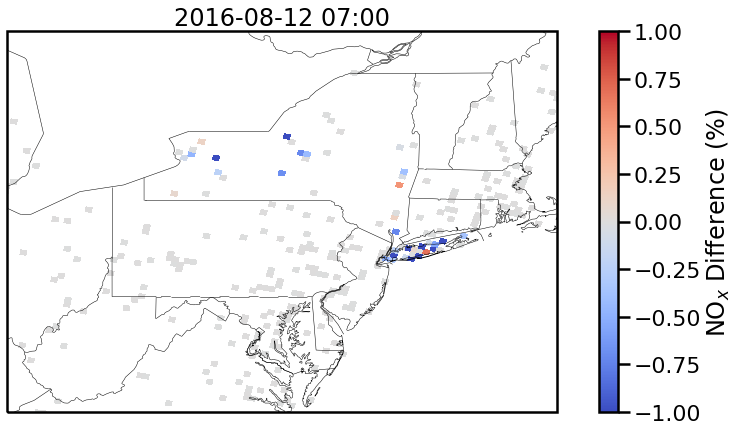

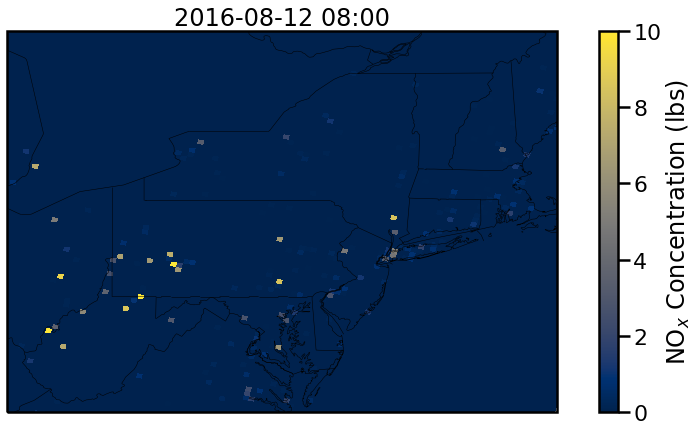

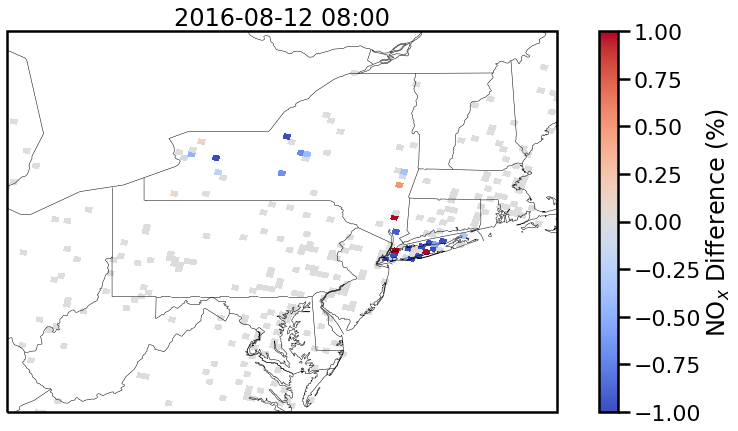

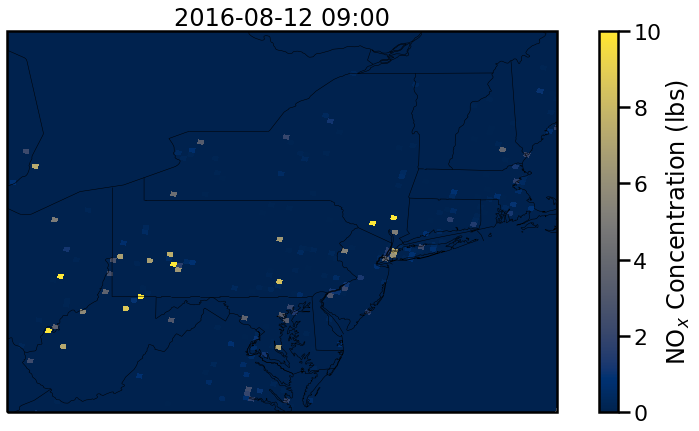

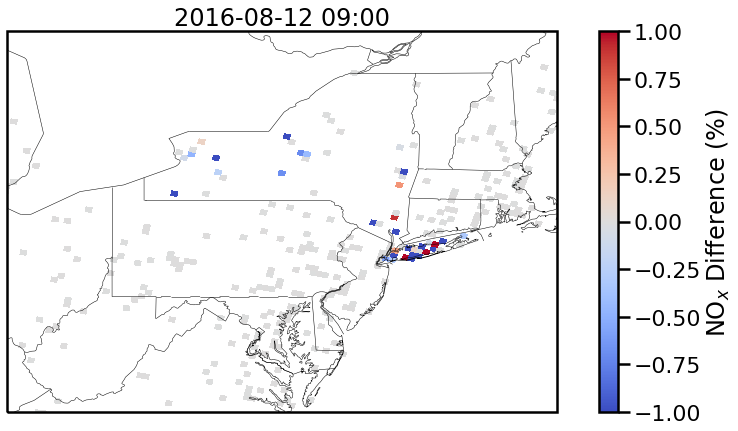

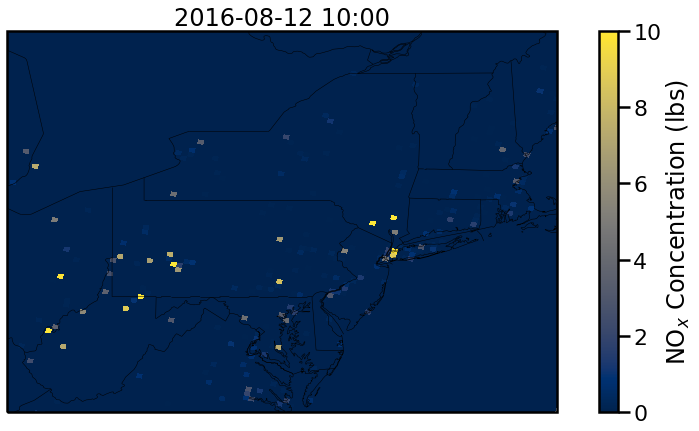

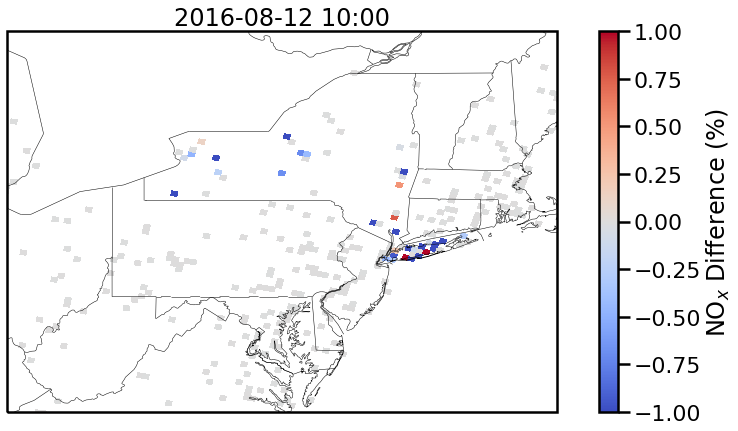

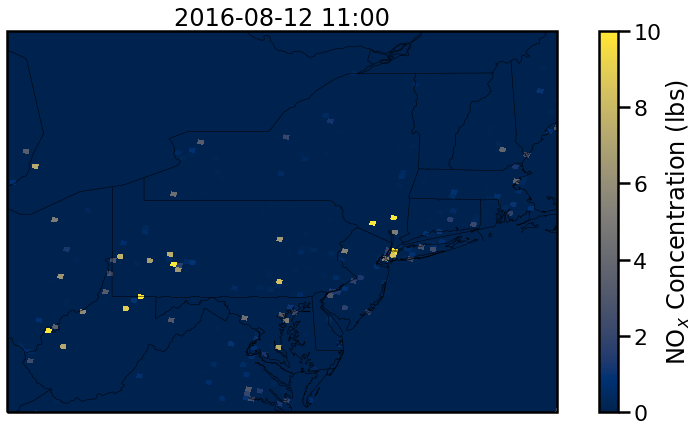

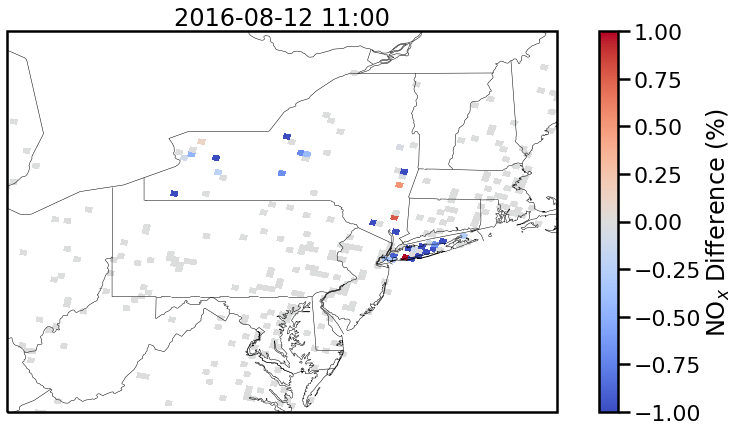

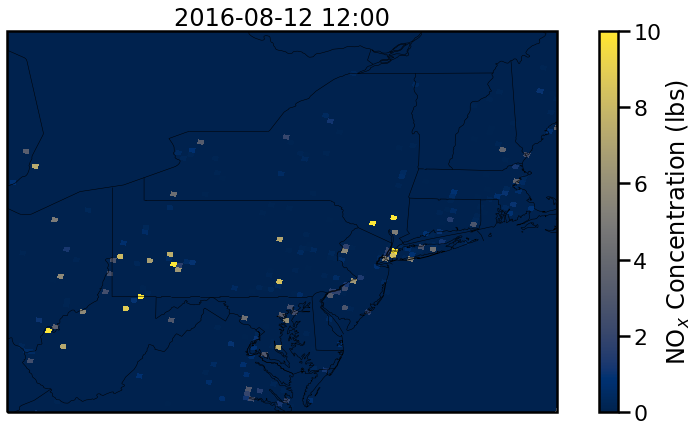

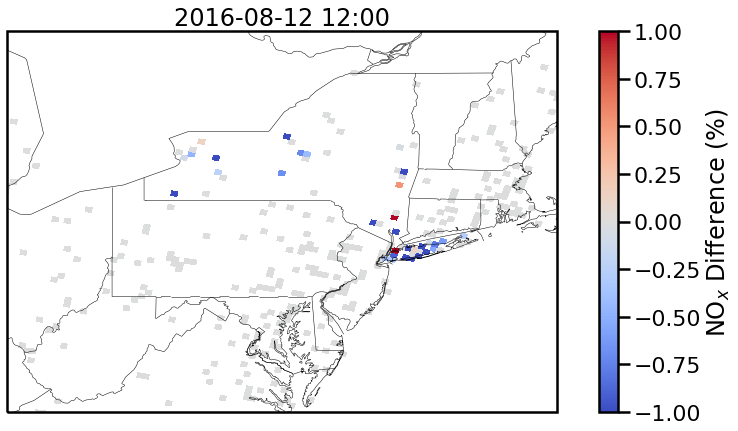

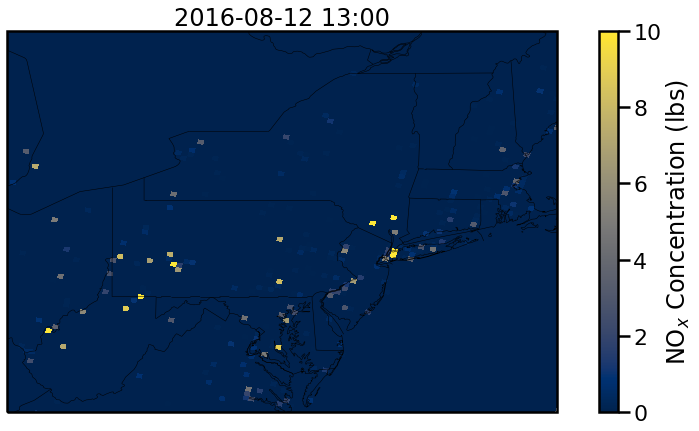

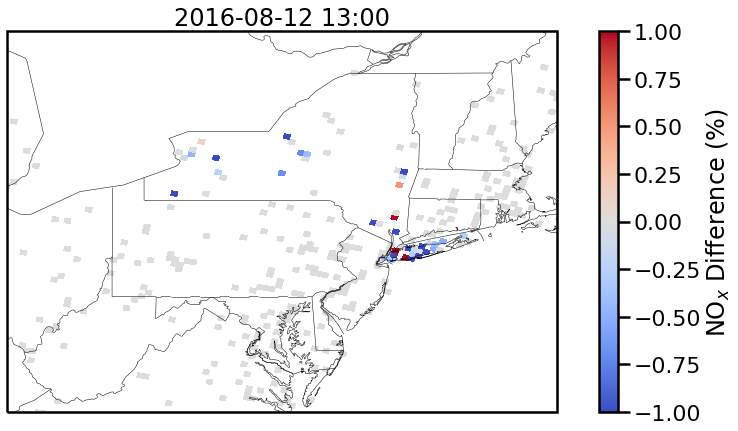

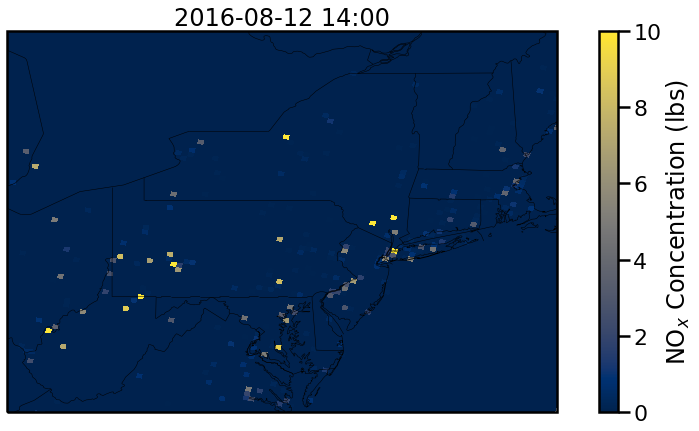

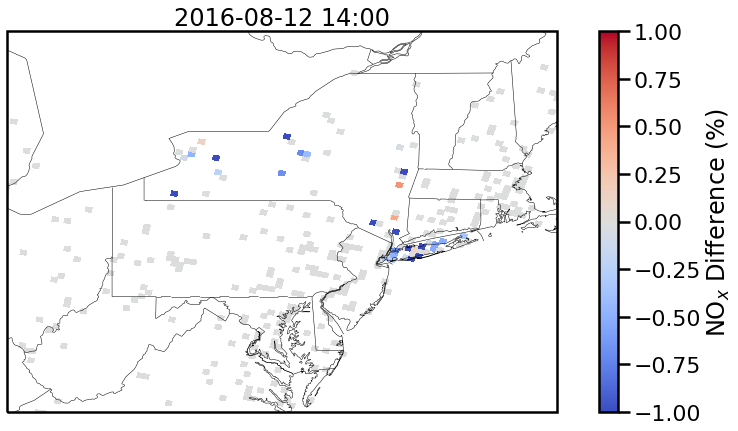

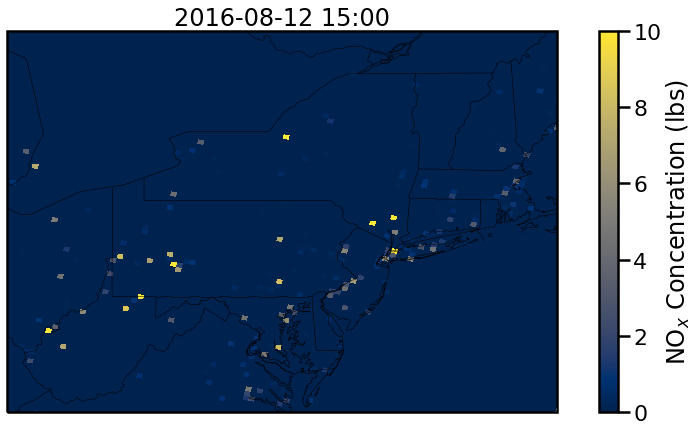

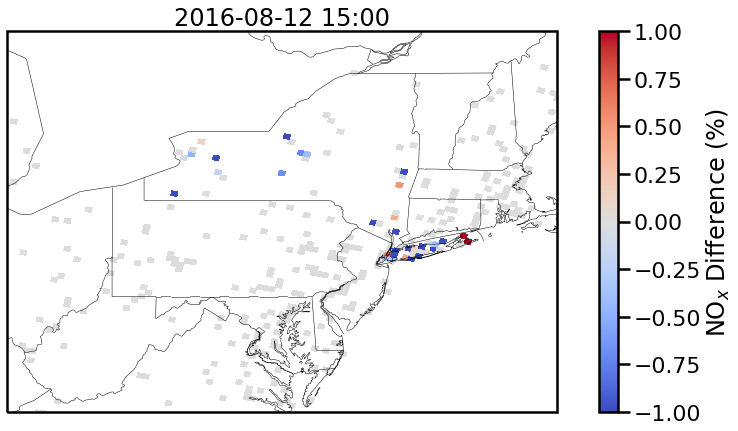

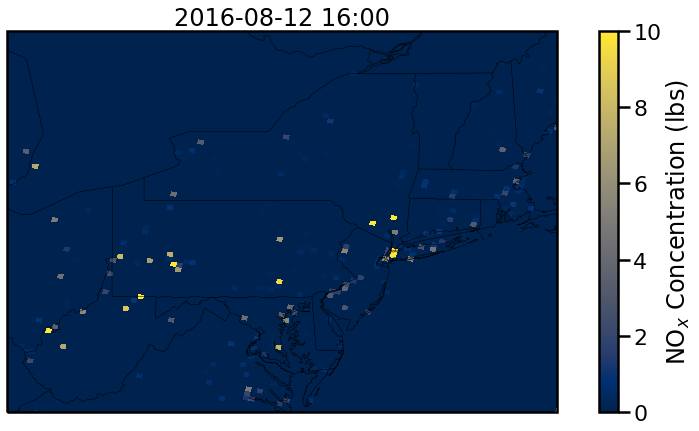

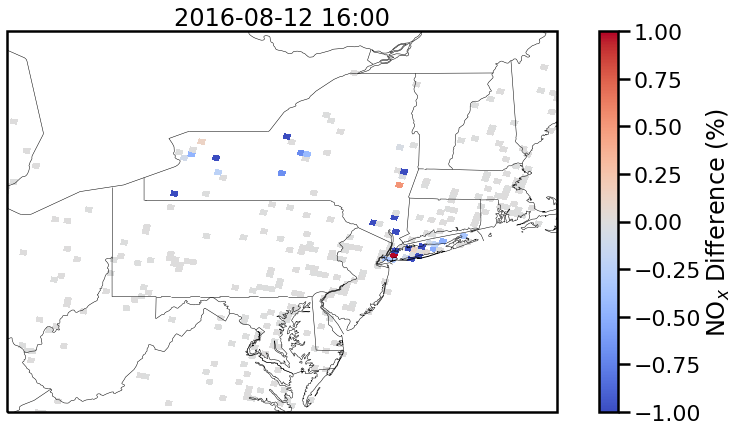

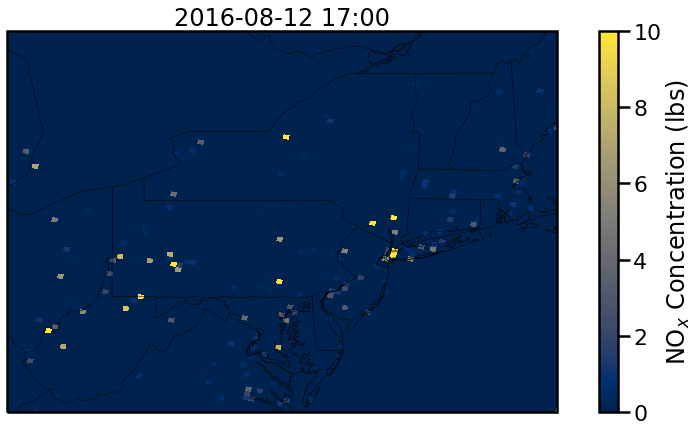

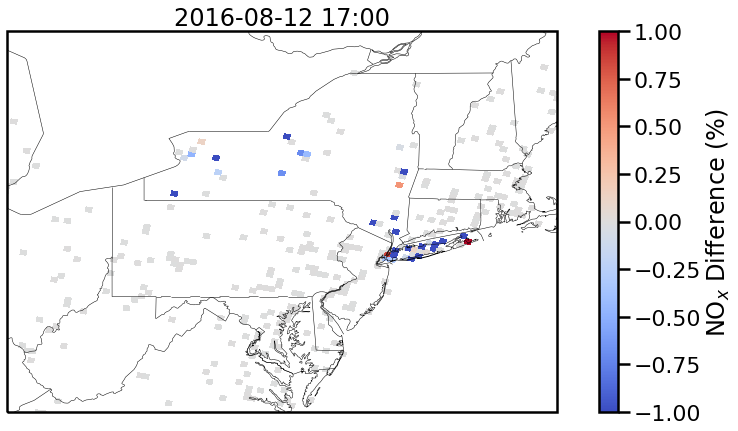

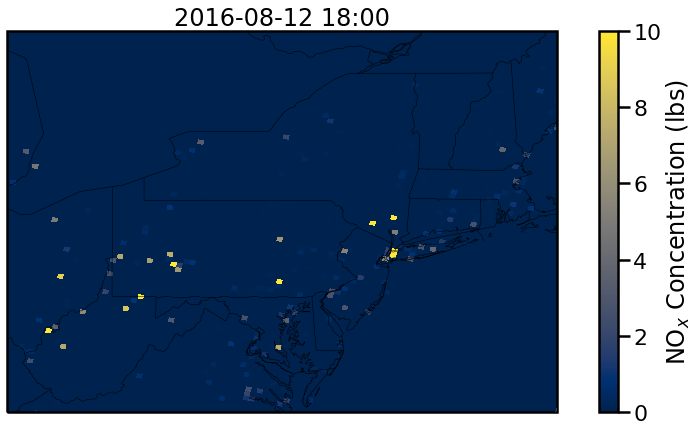

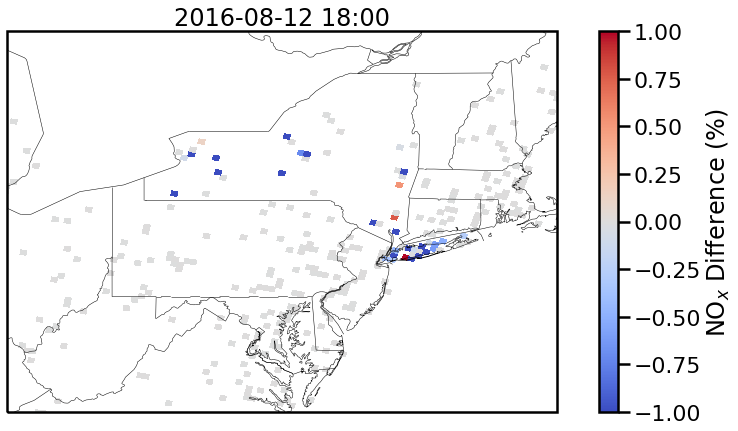

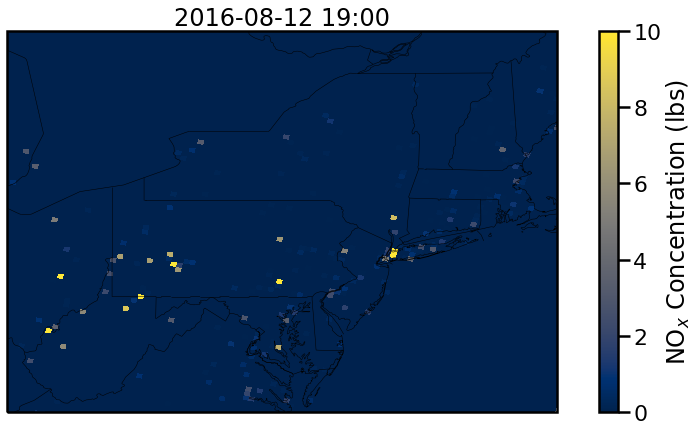

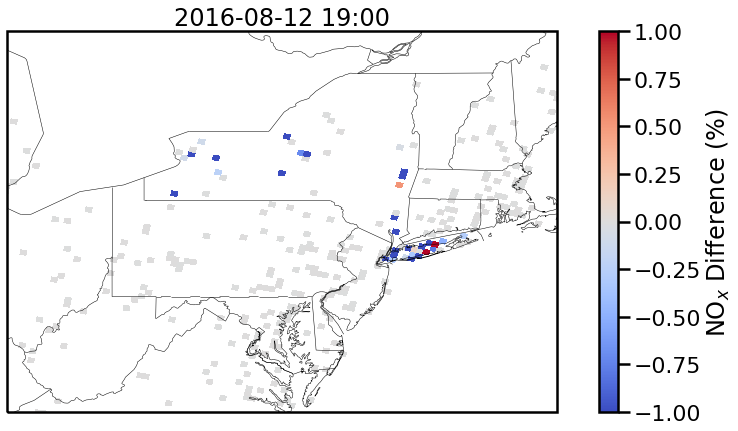

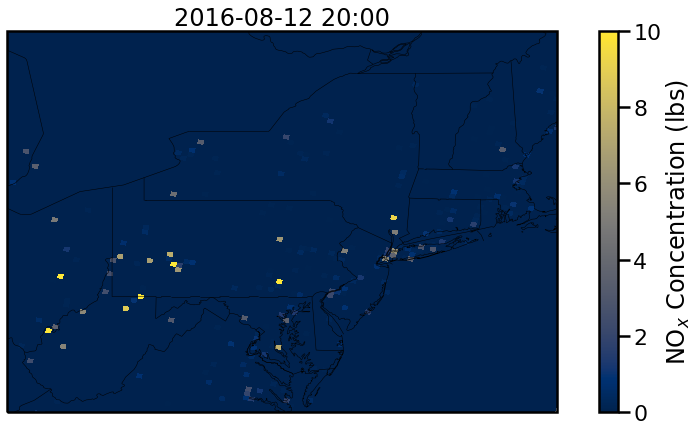

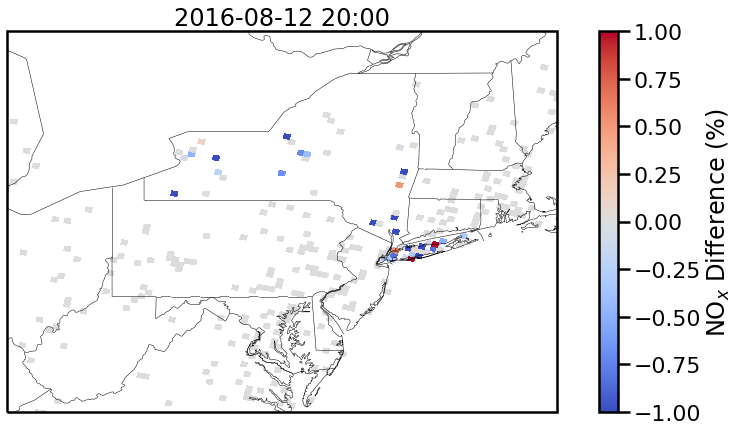

In [48]:
%%capture
# This plots the difference in Nox for each time slice
for ts in e_ren.time:
    tstr = ts.dt.strftime("%Y-%m-%d %H:%M").values
    print(tstr)
    ts = ts.values
    nox = e_ren.NO.sel(time=ts) + e_ren.NO2.sel(time=ts)
    nox_diff =  e_ren.NO.sel(time=ts) + e_ren.NO2.sel(time=ts) - e_base.NO.sel(time=ts) - e_base.NO2.sel(time=ts)
    nox_pct_diff = (e_ren.NO.sel(time=ts) + e_ren.NO2.sel(time=ts) - e_base.NO.sel(time=ts) - e_base.NO2.sel(time=ts)) / (e_base.NO.sel(time=ts) + e_base.NO2.sel(time=ts)) * 100
    plots.conc_compare(nox, nox_pct_diff, vmin1=0, vmax1=10, vmin2=-1, vmax2=1, 
                       cmap1=cm.get_cmap('cividis'), cmap2=cm.get_cmap('coolwarm'), 
                       extent = [-83, -70, 37, 46], 
                       cbar_label1='NO$_{x}$ Concentration (lbs)', cbar_label2='NO$_{x}$ Difference (%)', 
                       titlestr1=tstr, titlestr2=tstr, savefig=True, 
                       figpath1=f'../cmaqpy/data/plots/NOx_{tstr}.png', figpath2=f'../cmaqpy/data/plots/NOx_diff_{tstr}.png')

/home/jas983/anaconda3/envs/oshwind/lib/python3.8/site-packages/cartopy/mpl/geoaxes.py:1597: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  X, Y, C, shading = self._pcolorargs('pcolormesh', *args,
/home/jas983/anaconda3/envs/oshwind/lib/python3.8/site-packages/cartopy/mpl/geoaxes.py:1597: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  X, Y, C, shading = self._pcolorargs('pcolormesh', *args,
/home/jas983/anaconda3/envs/oshwind/lib/python3.8/site-packages/cartopy/mpl/geoaxes.py:1597: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonic

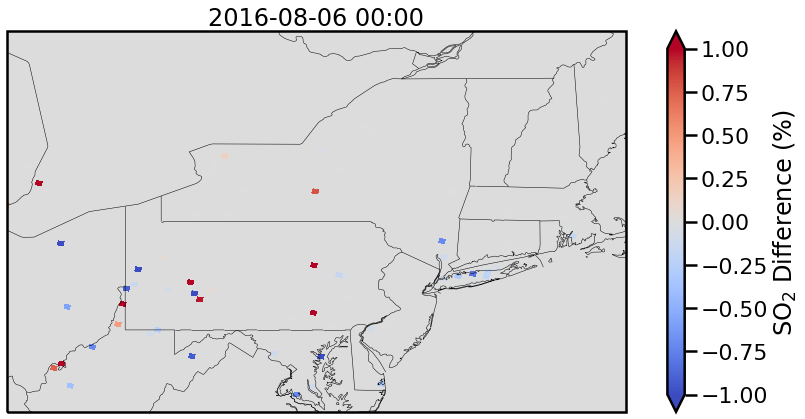

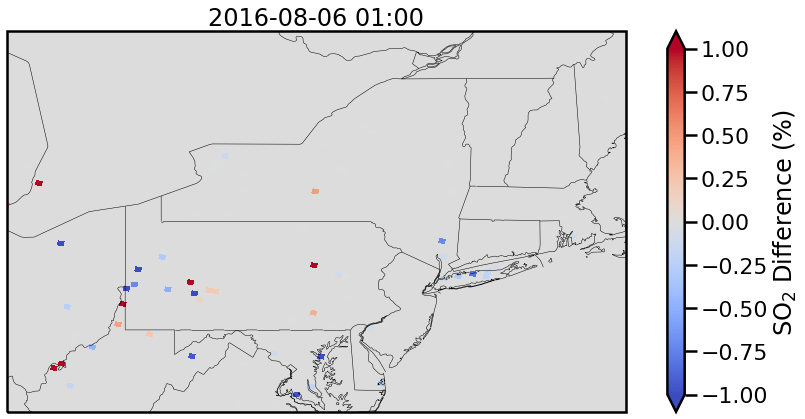

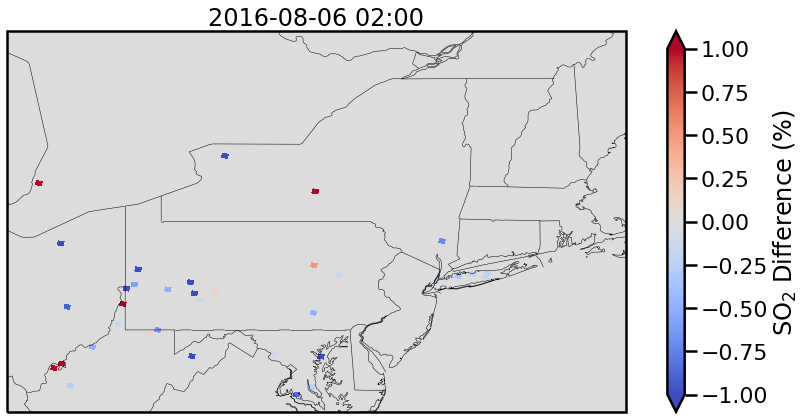

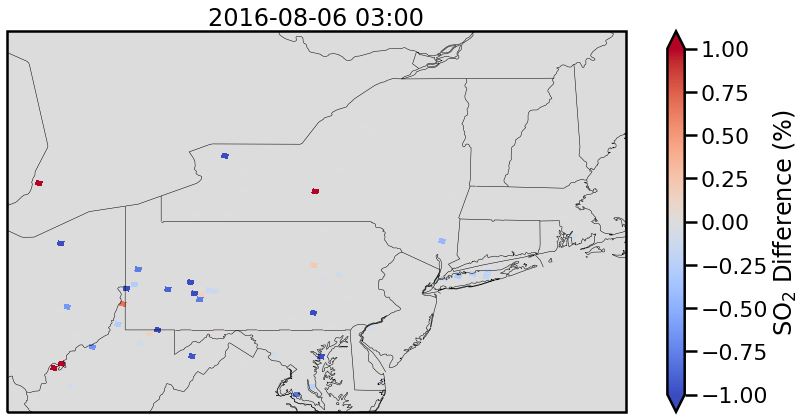

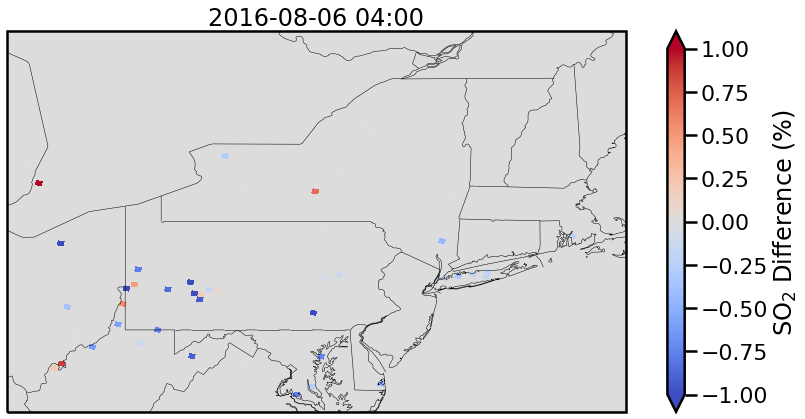

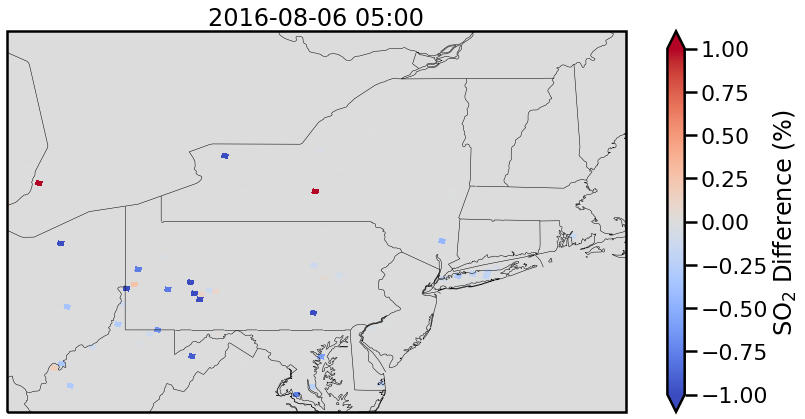

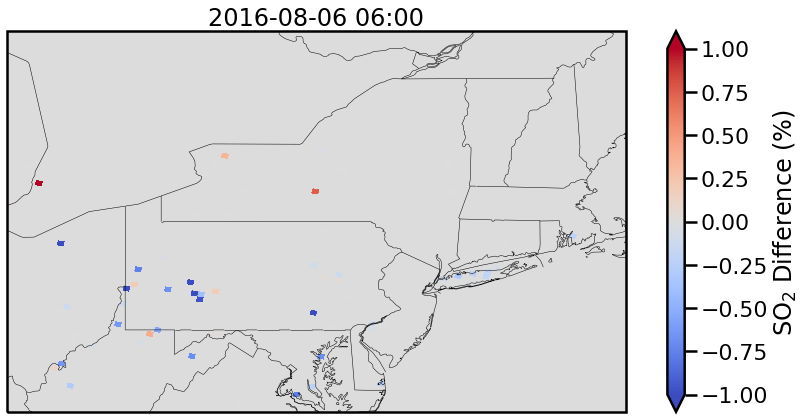

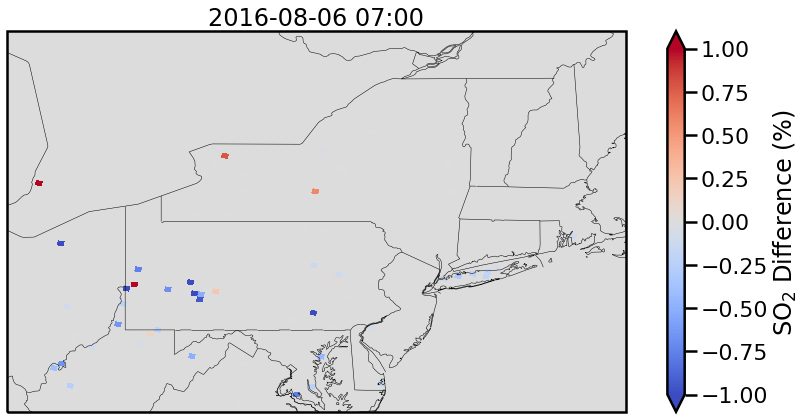

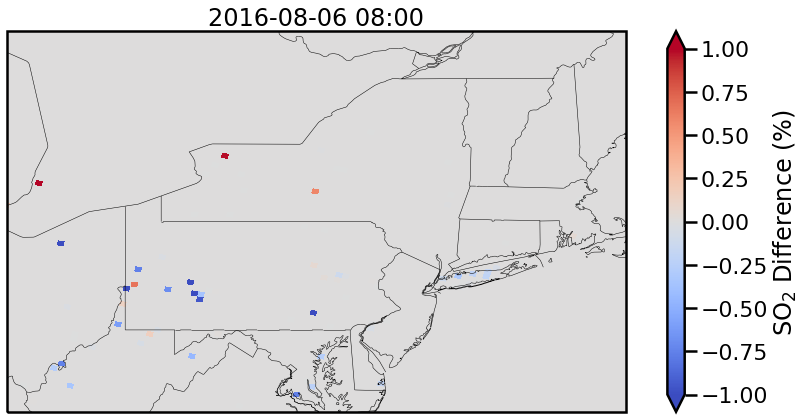

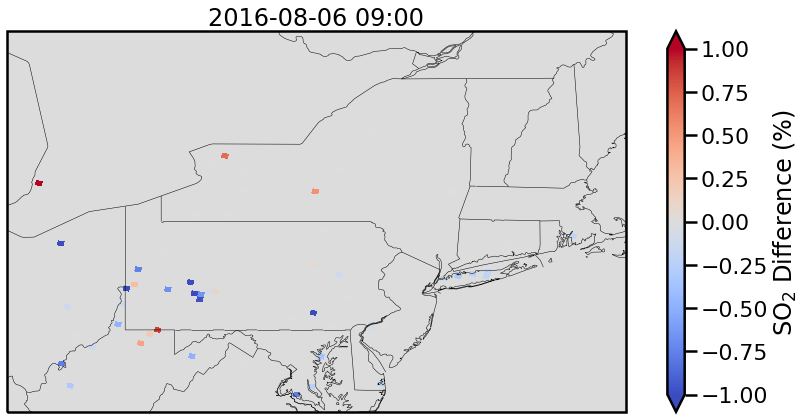

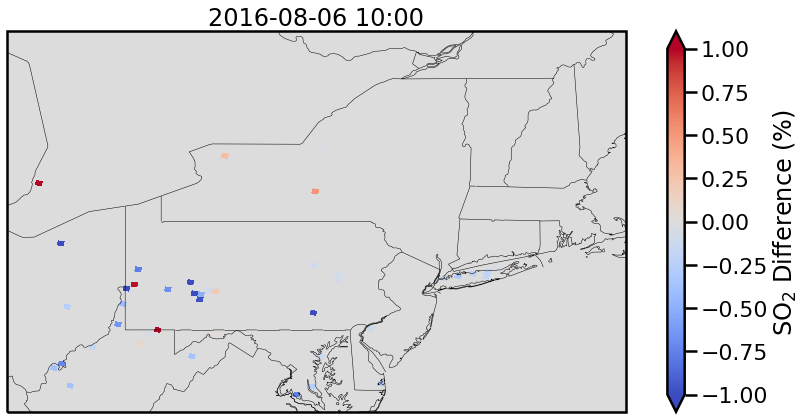

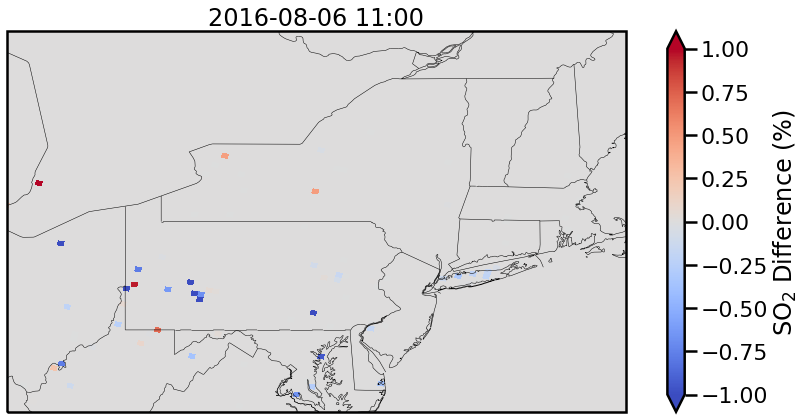

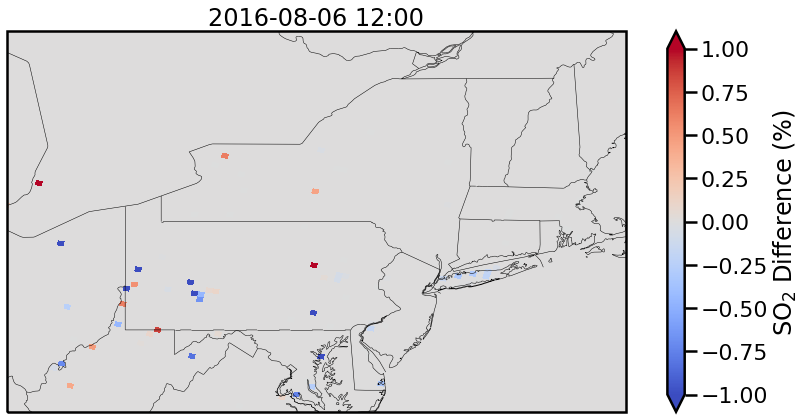

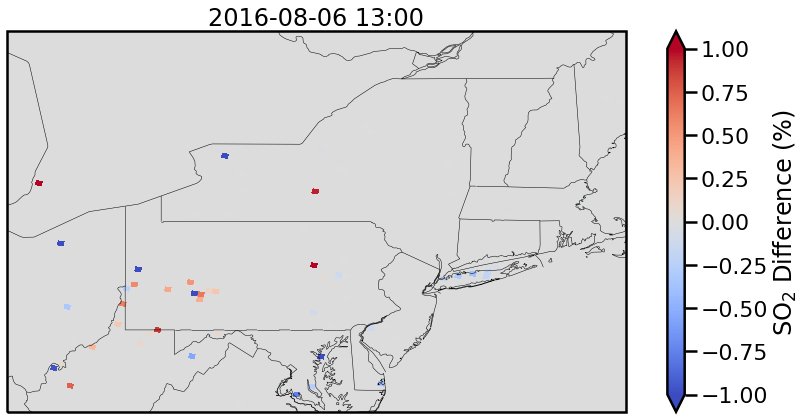

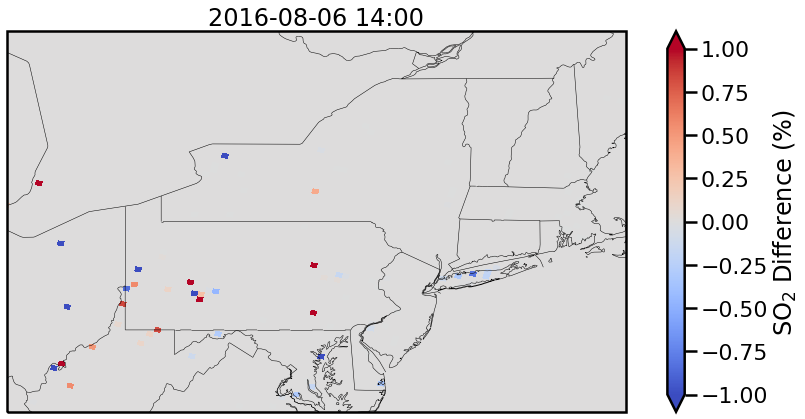

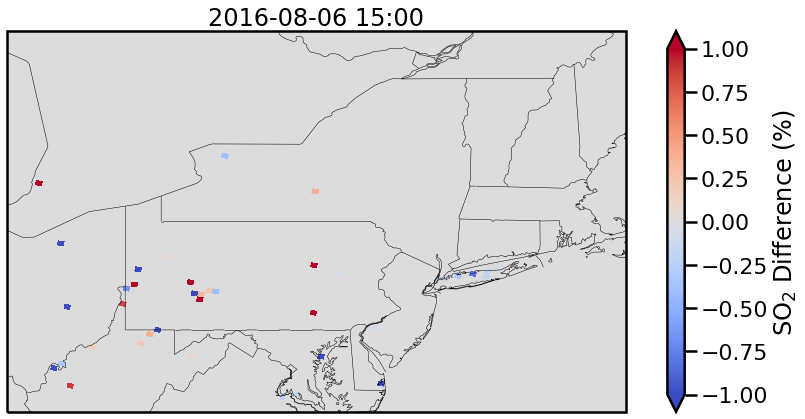

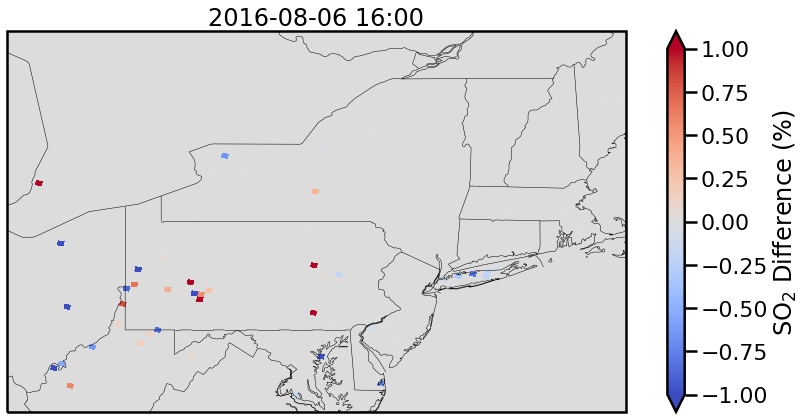

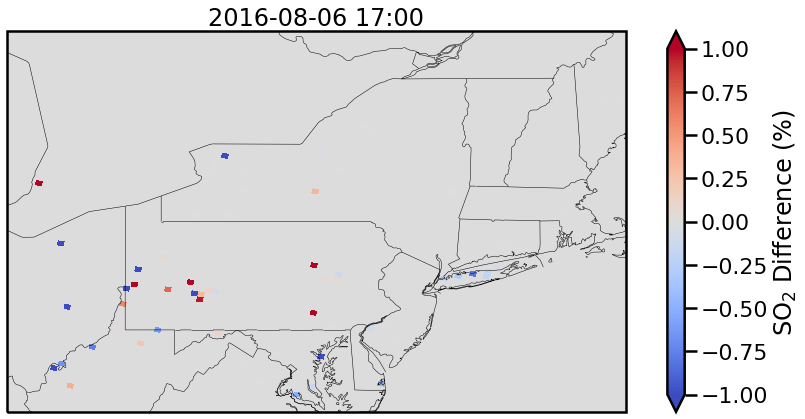

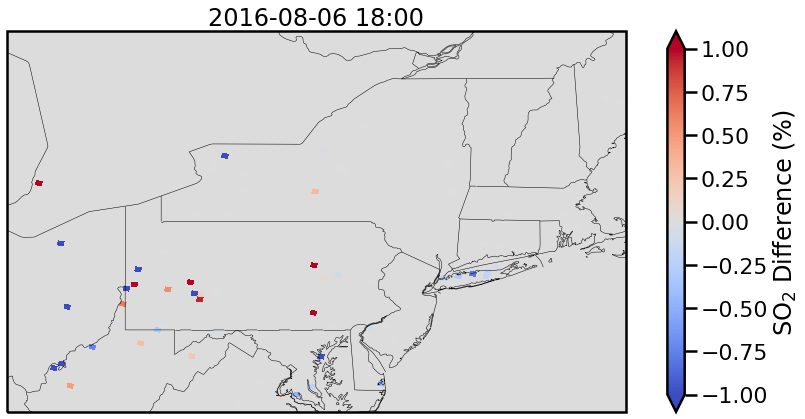

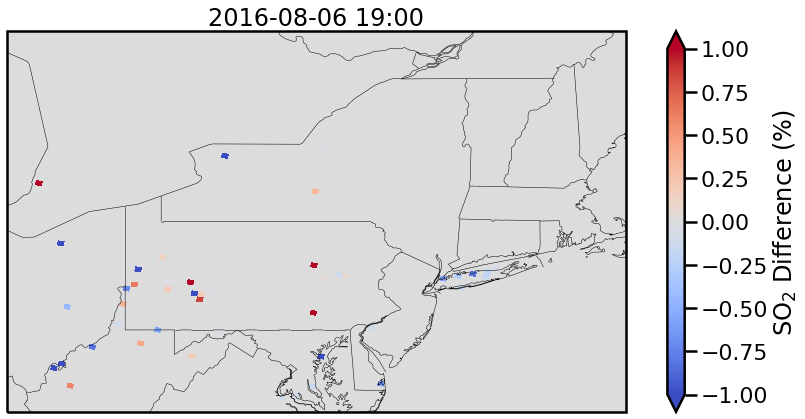

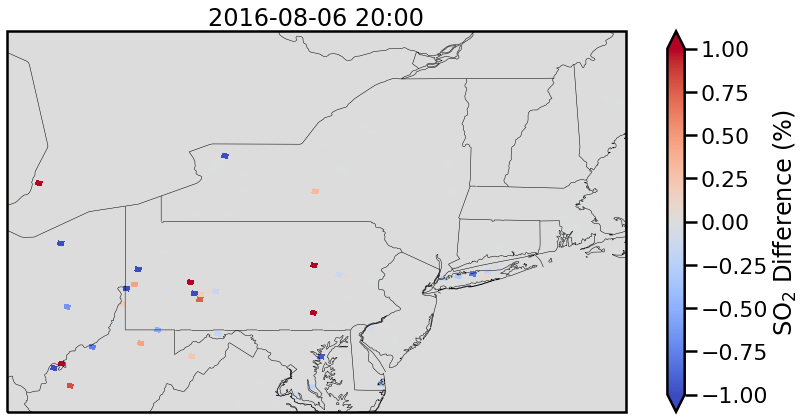

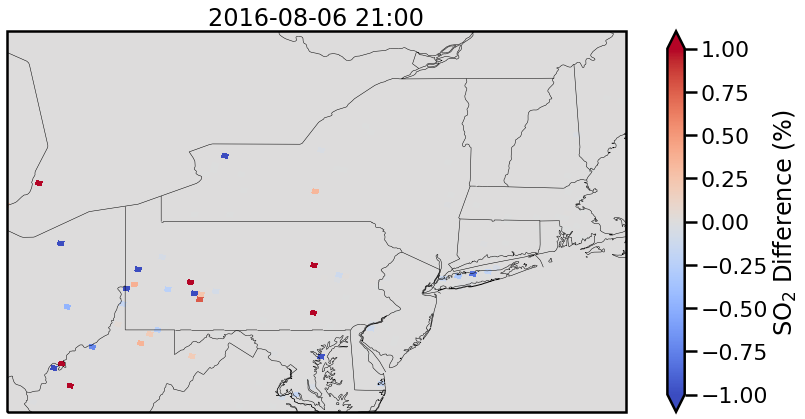

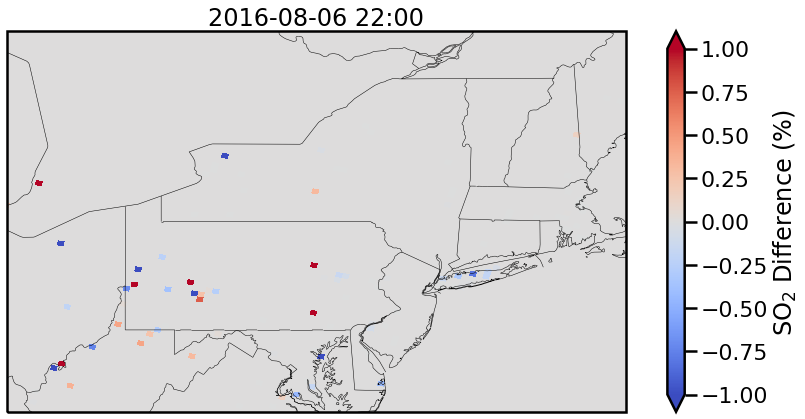

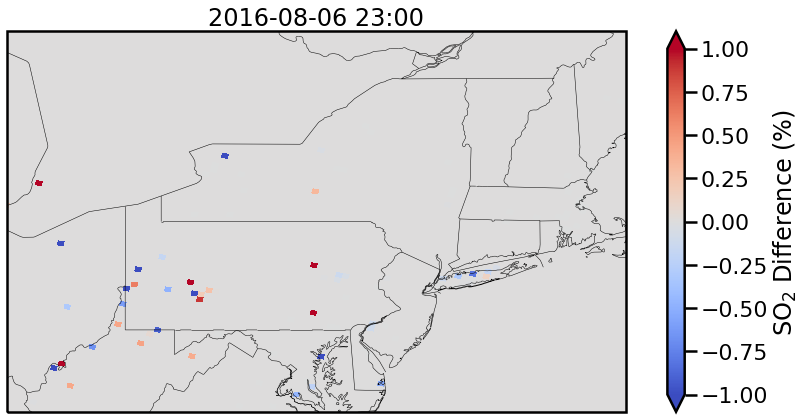

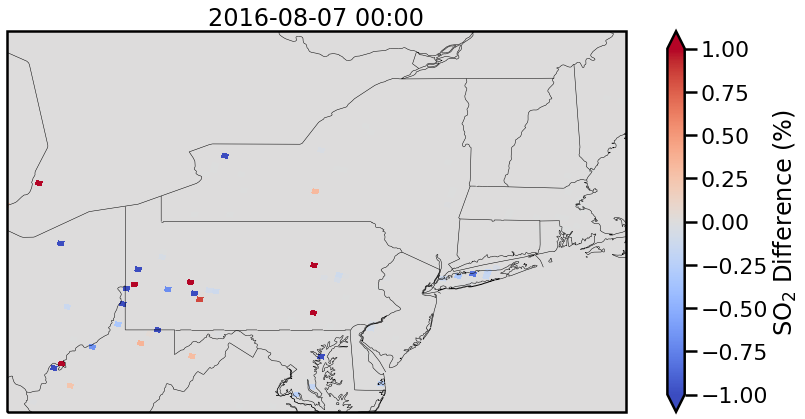

In [8]:
%%capture
# This plots the difference in SO2 for each time slice
for ts in e_ren.time:
    tstr = ts.dt.strftime("%Y-%m-%d %H:%M").values
    ts = ts.values
    so2_diff = (e_ren.SO2.sel(time=ts) - e_base.SO2.sel(time=ts)) / e_base.SO2.sel(time=ts) * 100
    plots.pollution_plot(so2_diff, vmin=-1, vmax=1, cmap=cm.get_cmap('coolwarm'), 
                         extent = [-83, -70, 38, 46],
                         cbar_label='SO$_{2}$ Difference (%)',
                         titlestr=tstr, savefig=True, figpath=f'../cmaqpy/data/plots/SO2_diff_{tstr}.png')